In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 
import plotly.express as px

0.13.2


In [13]:
df = pd.read_csv('/Users/artitakle/Documents/Cyber Security Attack Analysis/Data/Processed/cleaned_attacks.csv')

In [15]:
df.dtypes

Timestamp                     str
Source IP Address             str
Destination IP Address        str
Source Port                 int64
Destination Port            int64
Protocol                      str
Packet Length               int64
Packet Type                   str
Traffic Type                  str
Payload Data                  str
Malware Indicators            str
Anomaly Scores            float64
Alerts/Warnings               str
Attack Type                   str
Attack Signature              str
Action Taken                  str
Severity Level                str
User Information              str
Device Information            str
Network Segment               str
Geo-location Data             str
Proxy Information             str
Firewall Logs                 str
IDS/IPS Alerts                str
Log Source                    str
dtype: object

In [16]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [17]:
df.shape

(40000, 25)

In [18]:
df.info

<bound method DataFrame.info of                 Timestamp Source IP Address Destination IP Address  \
0     2023-05-30 06:33:58     103.216.15.12           84.9.164.252   
1     2020-08-26 07:08:30    78.199.217.198         66.191.137.154   
2     2022-11-13 08:23:25      63.79.210.48          198.219.82.17   
3     2023-07-02 10:38:46     163.42.196.10        101.228.192.255   
4     2023-07-16 13:11:07     71.166.185.76        189.243.174.238   
...                   ...               ...                    ...   
39995 2023-05-26 14:08:42      26.36.109.26         121.100.75.240   
39996 2023-03-27 00:38:27      17.21.163.81         196.108.134.78   
39997 2022-03-31 01:45:49     162.35.217.57            98.107.0.15   
39998 2023-09-22 18:32:38    208.72.233.205         173.79.112.252   
39999 2023-10-10 11:59:52     14.102.21.108           109.198.45.7   

       Source Port  Destination Port Protocol  Packet Length Packet Type  \
0            31225             17616     ICMP      

In [19]:
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,No IDS/IPS Alerts,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",No Proxy Information,Log Data,No IDS/IPS Alerts,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",No Proxy Information,No Firewall Logs,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,No Firewall Logs,Alert Data,Firewall


SECTION 1 — Attack Frequency Analysis

Find most common attacks

In [20]:
attack_counts = df['Attack Type'].value_counts()

print(attack_counts)

Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


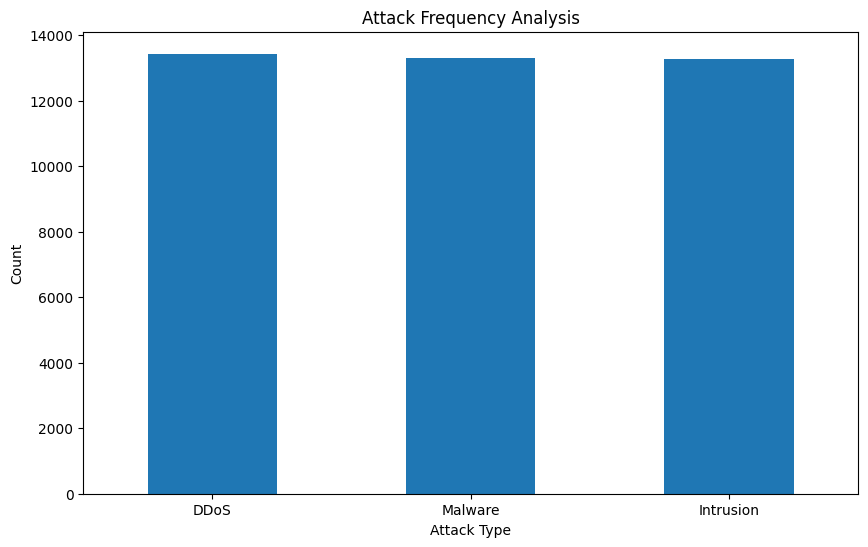

In [26]:
plt.figure(figsize=(10,6))

attack_counts.plot(kind='bar')

plt.title("Attack Frequency Analysis")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.xticks(rotation=360)

plt.show()

Insight:
1. Attack Frequency Analysis
Observation
DDoS, Malware, and Intrusion attacks occur at almost equal frequencies.
No single attack category dominates the dataset.
Business Insight
The organization faces a diverse cyber threat landscape rather than a single concentrated attack type.
Security monitoring systems should be designed to handle multiple attack vectors simultaneously.
Detection mechanisms must cover DDoS mitigation, malware detection, and intrusion prevention equally.
Resume-Level Insight
The network environment experiences balanced exposure to DDoS, Malware, and Intrusion attacks, indicating the need for multi-layered cyber defense strategies.

SECTION 2 — Severity Level Analysis

Analyze attack severity distribution.

In [27]:
severity_counts = df['Severity Level'].value_counts()

print(severity_counts)

Severity Level
Medium    13435
High      13382
Low       13183
Name: count, dtype: int64


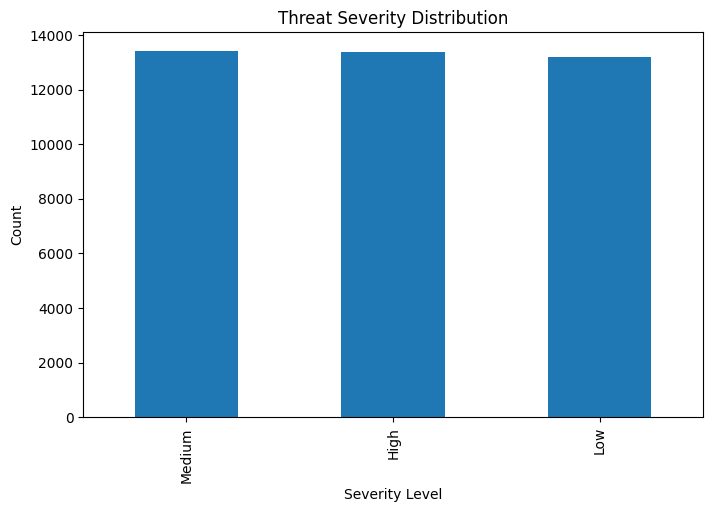

In [28]:
plt.figure(figsize=(8,5))

severity_counts.plot(kind='bar')

plt.title("Threat Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Count")

plt.show()

2. Threat Severity Distribution
Observation
High, Medium, and Low severity attacks are distributed almost equally.
High-severity threats are slightly prominent.
Business Insight
The system regularly encounters potentially dangerous attack events.
Security teams cannot focus only on low-level monitoring because high-risk attacks occur consistently.
Risk prioritization mechanisms should be implemented for faster incident response.
Resume-Level Insight
The dataset reveals a substantial proportion of high-severity cyber threats, emphasizing the importance of proactive threat mitigation and continuous security monitoring.

SECTION 3 — Top Malicious Source IPs

Find most suspicious IP addresses.

In [29]:
top_ips = df['Source IP Address'].value_counts().head(10)

print(top_ips)

Source IP Address
103.216.15.12      1
78.199.217.198     1
63.79.210.48       1
163.42.196.10      1
71.166.185.76      1
198.102.5.160      1
97.253.103.59      1
11.48.99.245       1
49.32.208.167      1
114.109.149.113    1
Name: count, dtype: int64


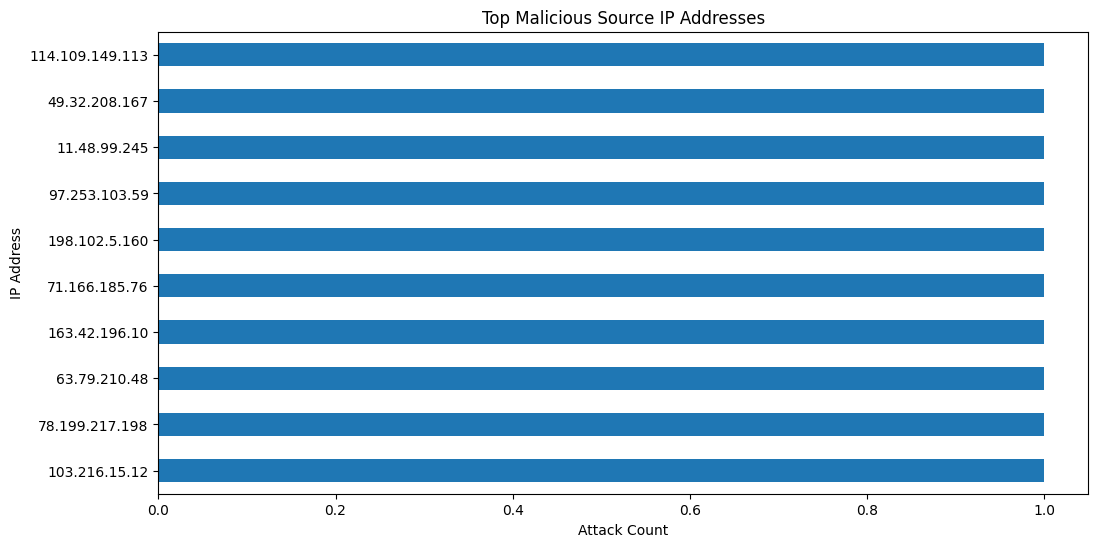

In [30]:
plt.figure(figsize=(12,6))

top_ips.plot(kind='barh')

plt.title("Top Malicious Source IP Addresses")
plt.xlabel("Attack Count")
plt.ylabel("IP Address")

plt.show()

Insight:
3. Top Malicious Source IP Addresses
Observation
Most source IPs appear only once.
No clear repetitive attacker pattern is visible.
Important Understanding
This suggests:
dataset may be synthetic/generated
OR
attacks originate from distributed sources.
Business Insight
Attack traffic appears highly distributed, making blacklist-only defense strategies less effective.
Organizations should rely on behavioral analytics and anomaly detection instead of static IP blocking.
Resume-Level Insight
Threat traffic originates from widely distributed IP sources, highlighting the need for anomaly-based intrusion detection systems rather than traditional blacklist approaches.

SECTION 4 — Protocol Distribution

Analyze attack protocols.

In [31]:
protocol_counts = df['Protocol'].value_counts()

print(protocol_counts)

Protocol
ICMP    13429
UDP     13299
TCP     13272
Name: count, dtype: int64


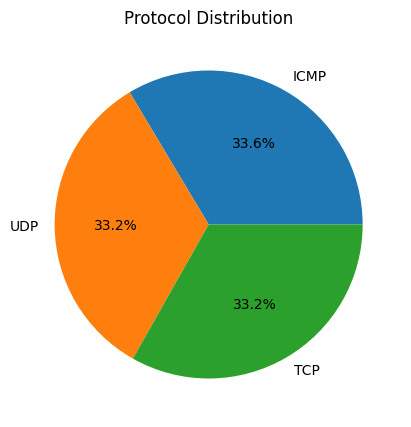

In [32]:
plt.figure(figsize=(8,5))

protocol_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Protocol Distribution")

plt.ylabel("")

plt.show()

Insight:
4. Protocol Distribution
Observation
ICMP, TCP, and UDP traffic are almost equally distributed.
ICMP has a slightly higher share.
Business Insight
Attack activity targets multiple communication protocols.
ICMP-based reconnaissance or ping flood behavior may require additional monitoring.
Security policies should include protocol-specific inspection rules.
Resume-Level Insight
The attack traffic demonstrates balanced protocol usage, with slightly elevated ICMP activity indicating potential reconnaissance or flooding behavior.

SECTION 5 — Hourly Attack Trends

Find attack spikes by hour.

In [33]:
df['hour'] = df['Timestamp'].dt.hour

In [34]:
hourly_attacks = df.groupby('hour').size()

print(hourly_attacks)

hour
0     1705
1     1630
2     1653
3     1652
4     1723
5     1673
6     1633
7     1623
8     1664
9     1639
10    1691
11    1665
12    1588
13    1737
14    1661
15    1720
16    1676
17    1671
18    1665
19    1665
20    1724
21    1682
22    1603
23    1657
dtype: int64


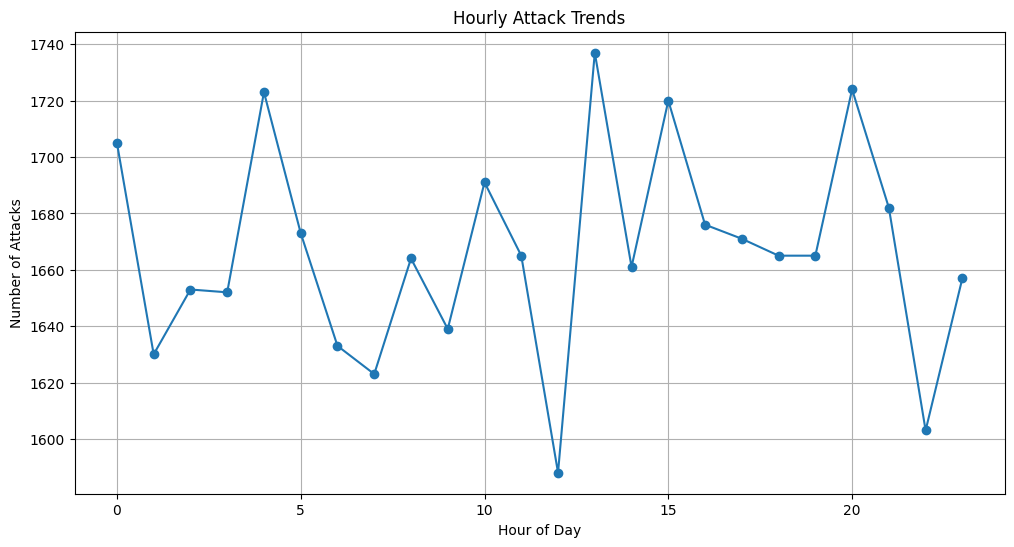

In [35]:
plt.figure(figsize=(12,6))

hourly_attacks.plot(kind='line', marker='o')

plt.title("Hourly Attack Trends")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Attacks")

plt.grid(True)

plt.show()

Insight:
5. Hourly Attack Trends
Observation
Attack frequency fluctuates throughout the day.
Peaks occur around:
Hour 13
Hour 15
Hour 20
Business Insight
Certain periods experience higher attack activity.
Security monitoring and alert systems should be strengthened during peak attack hours.
SOC resource allocation can be optimized using time-based attack analysis.
Resume-Level Insight
Time-series analysis identified multiple peak attack windows during the day, enabling more effective threat monitoring and security resource allocation.

SECTION 6 — Network Segment Analysis

Find vulnerable network segments.

In [36]:
segment_counts = df['Network Segment'].value_counts()

print(segment_counts)

Network Segment
Segment C    13408
Segment B    13319
Segment A    13273
Name: count, dtype: int64


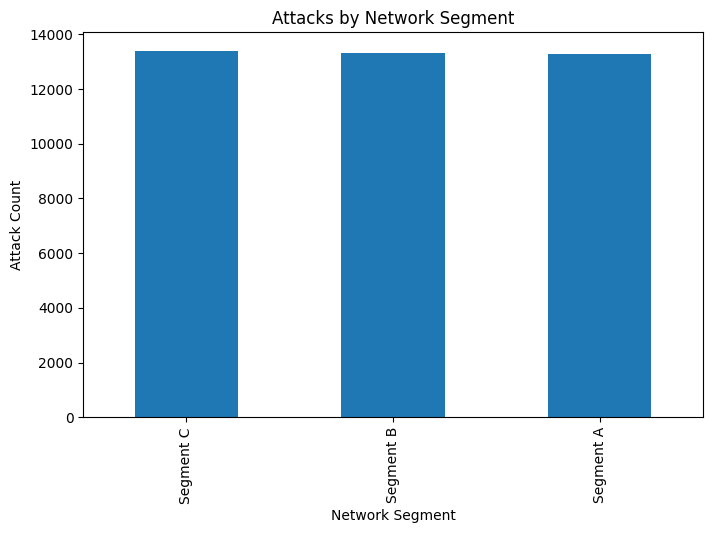

In [37]:
plt.figure(figsize=(8,5))

segment_counts.plot(kind='bar')

plt.title("Attacks by Network Segment")
plt.xlabel("Network Segment")
plt.ylabel("Attack Count")

plt.show()

Insight:

6.Cyber attack activity is uniformly distributed across all network segments, indicating that the organization’s infrastructure is broadly exposed to security threats rather than isolated to a single vulnerable area.
Resume-Level Insight
Network segment analysis revealed evenly distributed attack patterns across Segment A, B, and C, highlighting the importance of organization-wide security monitoring and balanced defensive controls.

SECTION 7 — Geo-location Analysis

Identify attack-prone regions.

In [38]:
top_locations = df['Geo-location Data'].value_counts().head(10)

print(top_locations)

Geo-location Data
Ghaziabad, Meghalaya          16
Kalyan-Dombivli, Jharkhand    15
Ghaziabad, Tripura            14
Ghaziabad, Uttarakhand        14
Ghaziabad, Jharkhand          13
Srikakulam, Uttarakhand       13
Motihari, Odisha              13
Aurangabad, Nagaland          13
Kottayam, Nagaland            13
Amroha, Sikkim                13
Name: count, dtype: int64


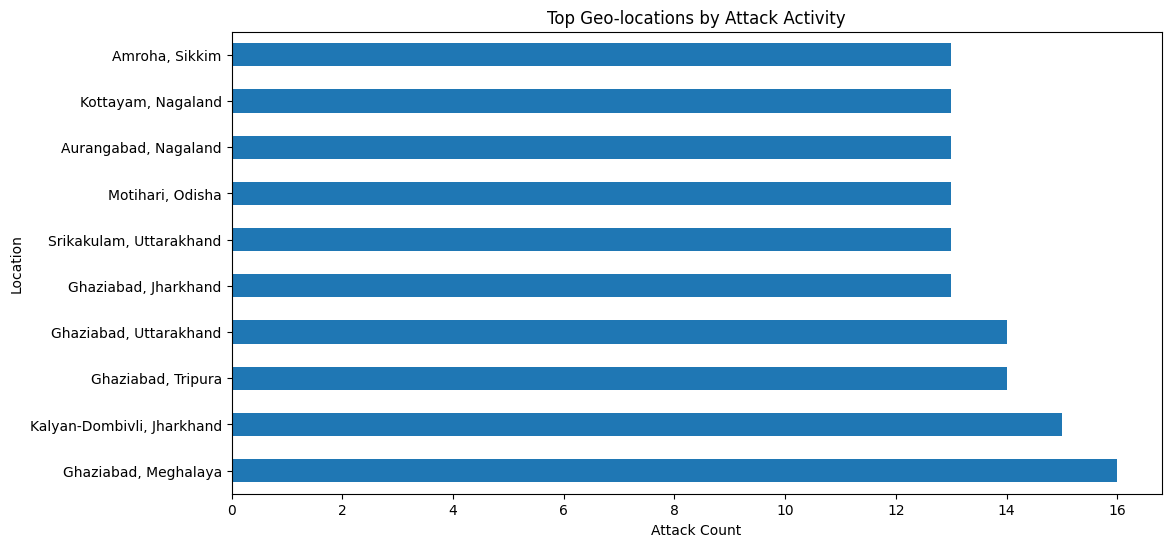

In [39]:
plt.figure(figsize=(12,6))

top_locations.plot(kind='barh')

plt.title("Top Geo-locations by Attack Activity")
plt.xlabel("Attack Count")
plt.ylabel("Location")

plt.show()

Insight:

7.Geo-location analysis indicates that attack activity originates from multiple geographically distributed regions, with locations such as Ghaziabad, Kalyan-Dombivli, and Srikakulam showing relatively higher attack frequencies. The absence of a single dominant location suggests that cyber threats are broadly distributed and potentially coordinated across different regions. This highlights the importance of implementing geographically aware threat monitoring, region-based traffic analysis, and distributed security controls to effectively detect and respond to suspicious network activity.

SECTION 8 — Correlation Heatmap

Analyze numerical relationships.

In [40]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation = numeric_df.corr()

print(correlation)

                  Source Port  Destination Port  Packet Length  Anomaly Scores
Source Port          1.000000         -0.005216       0.003657        0.004826
Destination Port    -0.005216          1.000000       0.002581       -0.003616
Packet Length        0.003657          0.002581       1.000000       -0.003599
Anomaly Scores       0.004826         -0.003616      -0.003599        1.000000


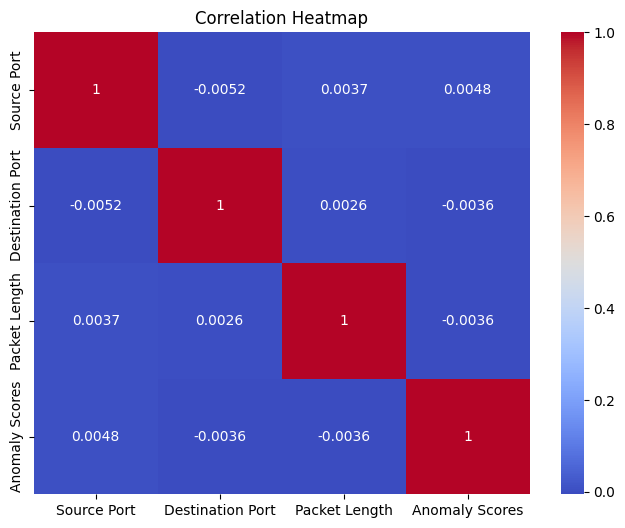

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Insight:

8.Correlation analysis shows extremely weak relationships among Source Port, Destination Port, Packet Length, and Anomaly Scores, indicating that no single numerical feature strongly influences anomalous network behavior independently. This suggests that cyber attack detection cannot rely on isolated network metrics alone and requires multi-feature analysis, behavioral monitoring, and advanced anomaly detection techniques to identify suspicious activity effectively. The low correlation also indicates diverse and complex attack patterns within the network traffic.

Key Findings:
- DDoS, Malware, and Intrusion attacks were the most frequently observed cyber threats across the network environment.
- High-severity attacks formed a significant portion of total detected threats, indicating elevated security risks.
- Attack traffic originated from highly distributed IP addresses, suggesting diverse and potentially coordinated attack sources.
- ICMP, TCP, and UDP protocols showed balanced malicious activity, with ICMP traffic slightly more prominent.
- Attack frequency fluctuated across different hours of the day, highlighting specific peak attack periods.
- Cyber attacks were distributed almost equally across all network segments, indicating organization-wide exposure to security threats.
- Geo-location analysis revealed geographically distributed attack activity across multiple regions rather than a single concentrated source.
- Correlation analysis showed weak relationships among numerical network features, suggesting that effective threat detection requires multi-feature behavioral analysis instead of relying on individual metrics alone.
- The overall analysis highlights the need for continuous monitoring, anomaly-based detection systems, protocol-level inspection, and organization-wide cyber defense strategies.